In [48]:
import numpy as np 
import torch
import qewton 

In [49]:
X = qewton.Variable("x", 3)
U = qewton.Variable("u", 3) # velocity is vector valued

In [50]:
fem_velocity = np.load("./data/stokes_pipe/velocity.npy").astype(np.float32)
mesh_coords = np.load("./data/stokes_pipe/mesh_coords.npy").astype(np.float32)

fem_velocity = torch.tensor(fem_velocity)
mesh_coords = torch.tensor(mesh_coords)


In [51]:
input_config = qewton.DataConfiguration(
    qewton.BatchAxes(len(mesh_coords)), qewton.FeatureAxes(X)
)
output_config = qewton.DataConfiguration(
    qewton.BatchAxes(len(mesh_coords)), qewton.FeatureAxes(U)
)

dataset = qewton.data.ArrayLikeDataSet(
    data=[mesh_coords, fem_velocity], data_configs=[input_config, output_config]
)

In [52]:
batch_size = int(0.8 * len(mesh_coords))
data_loader = qewton.data.DataLoader(
    data_set=dataset,
    batch_size=batch_size,
    splitting_ratio=(0.8, 0.2, 0.0),
    shuffle_data=True,
)

In [53]:
model = qewton.FCN(
    in_neurons=X,
    hidden_neurons=25,
    out_neurons=U,
    n_hidden_layers=6,
    activation=qewton.bb.Tanh,
)

In [54]:
constraint = qewton.constraints.MSEConstraint()

computation_graph = qewton.Graph()

computation_graph.connect(data_loader.get_output_port(X), model)
computation_graph.connect(model, constraint.input_1)
computation_graph.connect(data_loader.get_output_port(U), constraint.input_2)

computation_graph.setup()


In [55]:
adam_phase = qewton.optim.OptimizationPhase(
    optimizer=qewton.optim.Adam(),
    lr=0.001,
    max_iterations=5000,
)

lbfgs_phase = qewton.optim.OptimizationPhase(
    optimizer=qewton.optim.LBFGS(),
    lr=0.1,
    max_iterations=200,
    optimizer_args={"max_eval": 10},
)

trainer = qewton.optim.GraphBasedTrainer(
    optimization_phases=[adam_phase, lbfgs_phase],
    graphs=[computation_graph],
    training_objectives=[constraint],
    device="cuda:0",
)

trainer.run()

Optimization Phase 2: 100%|██████████| 200/200 [00:31<00:00,  6.35it/s, loss=0.000707]


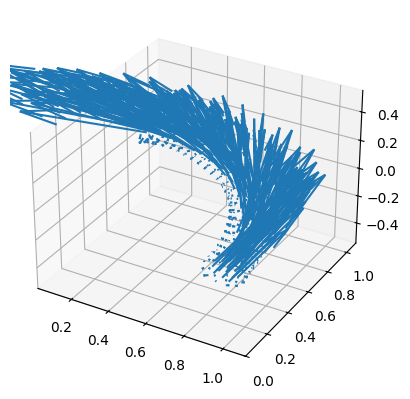

Performance at test points:
MSE between PINN and FEM: 0.0007499582296799787
Relative MSE: 0.0012283029442147415


/tmp/ipykernel_749938/3448012465.py:38: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  error_point_wise = np.linalg.norm(model_out-fem_velocity, ord=2, axis=1)[test_N:]


In [56]:
import torch
import matplotlib.pyplot as plt
import numpy as np 

fem_velocity = np.load("./data/stokes_pipe/velocity.npy")
mesh_coords = np.load("./data/stokes_pipe/mesh_coords.npy").astype(np.float32)

model.to("cpu")
model_out = model(torch.tensor(mesh_coords))[:, :3].detach().cpu()

x, y, z = mesh_coords[:, 0], mesh_coords[:, 1], mesh_coords[:, 2]
u, v, w = model_out[:, 0], model_out[:, 1], model_out[:, 2]

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.quiver(
    x, y, z,
    u, v, w,
    length=1.0
)

mid_x = (x.max() + x.min()) * 0.5
mid_y = (y.max() + y.min()) * 0.5
mid_z = (z.max() + z.min()) * 0.5

max_range = (
    np.array([x.max() - x.min(), y.max() - y.min(), z.max() - z.min()]).max() / 2.0
)

ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)

plt.show()
print("Performance at test points:")
test_N = int(0.8 * len(mesh_coords))
error_point_wise = np.linalg.norm(model_out-fem_velocity, ord=2, axis=1)[test_N:]
velocity_l2 = np.linalg.norm(fem_velocity, ord=2, axis=1)[test_N:]
mse_error = np.mean(error_point_wise**2)
print("MSE between PINN and FEM:", mse_error)
print("Relative MSE:", np.mean((error_point_wise / (velocity_l2 + 1.e-4))**2))